# Singapore Energy Demand Forecast
## ML Project: Predicting Electricity Consumption from Weather
> **Location:** Singapore (1.3521°N, 103.8198°E) | **Data:** Open-Meteo + EMA | **Period:** 2023–2024

This notebook implements a complete machine learning pipeline to predict Singapore's next-day electricity demand in MWh using historical weather conditions. The project trains two complementary models:
- **Regression Model**: Predicts exact MWh demand
- **Classification Model**: Predicts demand level (High/Medium/Low)

Both models support three prediction modes: historical dates (2023–2024), tomorrow (using live weather), and future dates (up to 16 days using forecast API).

## Step 1: Import Required Libraries

In [1]:
!pip install catboost xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Visualization settings
import matplotlib
_styles = matplotlib.style.available
_pref = ['seaborn-v0_8-darkgrid', 'seaborn-darkgrid']
_style = next((s for s in _pref if s in _styles), 'ggplot')
plt.style.use(_style)
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Step 2: Data Collection – Weather & Electricity Demand

### 2.1 Fetch Open-Meteo Weather Data

Singapore coordinates: Latitude 1.3521, Longitude 103.8198
- Daily variables: Temperature (max, min, mean), Humidity, Precipitation, Wind Speed, Apparent Temperature
- Period: 2023–2024 (730 days)

In [4]:
# Fetch Open-Meteo weather data for Singapore (2023-2024)
def fetch_weather_data():
    """Fetch daily weather data from Open-Meteo API for Singapore (with synthetic fallback)"""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 1.3521,
        "longitude": 103.8198,
        "start_date": "2023-01-01",
        "end_date": "2024-12-31",
        "daily": "temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_max,precipitation_sum,wind_speed_10m_max,apparent_temperature_max",
        "timezone": "Asia/Singapore"
    }

    print("Fetching weather data from Open-Meteo...")
    try:
        response = requests.get(url, params=params, timeout=15)
        if response.status_code == 200:
            data = response.json()
            weather_df = pd.DataFrame({
                'date': pd.to_datetime(data['daily']['time']),
                'temp_max': data['daily']['temperature_2m_max'],
                'temp_min': data['daily']['temperature_2m_min'],
                'temp_mean': data['daily']['temperature_2m_mean'],
                'humidity_max': data['daily']['relative_humidity_2m_max'],
                'precipitation': data['daily']['precipitation_sum'],
                'wind_speed': data['daily']['wind_speed_10m_max'],
                'apparent_temp_max': data['daily']['apparent_temperature_max']
            })
            print(f"✓ Weather data fetched from API: {len(weather_df)} days")
            return weather_df
        else:
            print(f"⚠ API returned status {response.status_code}. Generating synthetic weather data...")
    except Exception as e:
        print(f"⚠ API call failed ({e}). Generating synthetic weather data...")

    # ── Synthetic fallback: realistic Singapore climate ──
    np.random.seed(42)
    dates = pd.date_range("2023-01-01", "2024-12-31", freq="D")
    n = len(dates)
    doy = np.array([d.dayofyear for d in dates])

    # Singapore is near-equatorial; temp varies slightly with monsoon seasons
    temp_mean_base = 27.5 + 1.5 * np.sin(2 * np.pi * (doy - 60) / 365)
    temp_mean = temp_mean_base + np.random.normal(0, 0.8, n)
    temp_max  = temp_mean + np.random.uniform(2.5, 4.5, n)
    temp_min  = temp_mean - np.random.uniform(2.0, 3.5, n)
    humidity_max = np.clip(85 + 5 * np.sin(2 * np.pi * (doy - 30) / 365) + np.random.normal(0, 4, n), 60, 100)
    precipitation = np.abs(np.random.exponential(3.5, n))
    wind_speed = np.abs(10 + np.random.normal(0, 3, n))
    apparent_temp_max = temp_max + 2.0 * humidity_max / 100 + np.random.normal(0, 0.5, n)

    weather_df = pd.DataFrame({
        'date': dates,
        'temp_max': np.round(temp_max, 1),
        'temp_min': np.round(temp_min, 1),
        'temp_mean': np.round(temp_mean, 1),
        'humidity_max': np.round(humidity_max, 1),
        'precipitation': np.round(precipitation, 1),
        'wind_speed': np.round(wind_speed, 1),
        'apparent_temp_max': np.round(apparent_temp_max, 1)
    })
    weather_df = weather_df.fillna(method='ffill')
    weather_df.set_index('date', inplace=True)
    print(f"✓ Synthetic weather data generated: {len(weather_df)} days")
    return weather_df

weather_df = fetch_weather_data()
print(f"\nWeather Data Shape: {weather_df.shape}")
print(weather_df.head(10))


Fetching weather data from Open-Meteo...
✓ Weather data fetched from API: 731 days

Weather Data Shape: (731, 8)
        date  temp_max  temp_min  temp_mean  humidity_max  precipitation  \
0 2023-01-01      28.9      23.4       25.8            91            0.1   
1 2023-01-02      30.2      23.0       26.2            95            1.1   
2 2023-01-03      29.9      23.5       25.7            96            8.5   
3 2023-01-04      28.9      23.5       25.7            94            1.1   
4 2023-01-05      30.0      23.5       25.8            96            4.6   
5 2023-01-06      29.2      23.9       26.1            94            2.4   
6 2023-01-07      29.8      23.1       25.7            96            4.6   
7 2023-01-08      30.2      23.1       26.3            97            0.4   
8 2023-01-09      29.6      23.2       26.0            97            1.8   
9 2023-01-10      29.2      23.1       26.1            97            6.9   

   wind_speed  apparent_temp_max  
0        16.4  

### 2.2 Load EMA Electricity Demand Data

The Energy Market Authority publishes half-hourly system demand data. We aggregate to daily MWh totals.

In [5]:
# Load EMA electricity demand data (with synthetic fallback if CSV not found)
import pathlib

candidate_paths = [
    pathlib.Path('ema_daily_demand.csv'),
    pathlib.Path('data') / 'ema_daily_demand.csv',
    pathlib.Path('ema_demand.csv'),
    pathlib.Path('data') / 'ema_demand.csv'
]

demand_file = next((path for path in candidate_paths if path.exists()), None)

def load_demand_data(path):
    demand_df = pd.read_csv(path, parse_dates=['date'])
    if 'demand_mwh' not in demand_df.columns:
        raise ValueError(
            "The demand CSV must contain a 'demand_mwh' column. "
            f"Found columns: {', '.join(demand_df.columns)}"
        )
    demand_df = demand_df[['date', 'demand_mwh']].copy()
    demand_df = demand_df.sort_values('date').reset_index(drop=True)
    if len(demand_df) < 31:
        raise ValueError(
            f"Loaded demand data has only {len(demand_df)} rows. "
            "The model requires at least 31 consecutive daily rows."
        )
    print(f"✓ Electricity demand data loaded: {len(demand_df)} days")
    return demand_df

# When file not found
def generate_synthetic_demand(weather_df):
    """Generate realistic Singapore daily electricity demand (MWh) from weather."""
    np.random.seed(42)
    dates = weather_df['date'].values
    temp_mean = weather_df['temp_mean'].values
    humidity_max = weather_df['humidity_max'].values
    n = len(dates)

    # Singapore system demand ~20,000–24,000 MWh/day; higher on hot/humid days
    base_demand = 21500
    temp_effect = 220 * (temp_mean - 27.5)
    humidity_effect = 30 * (humidity_max - 85)
    # Weekend / holiday reduction
    dow = pd.DatetimeIndex(dates).dayofweek
    day_effect = np.where(dow >= 5, -800, 0)
    noise = np.random.normal(0, 150, n)
    demand = base_demand + temp_effect + humidity_effect + day_effect + noise
    demand_df = pd.DataFrame({'date': pd.DatetimeIndex(dates), 'demand_mwh': np.round(demand, 1)})
    return demand_df

if demand_file is None:
    print("⚠ EMA demand CSV not found. Generating synthetic demand data from weather...")
    demand_df = generate_synthetic_demand(weather_df)
    print(f"✓ Synthetic electricity demand data generated: {len(demand_df)} days")
else:
    print(f"Loading demand data from: {demand_file}")
    demand_df = load_demand_data(demand_file)
    print(f"\nDemand File Path: {demand_file.resolve()}")

print(f"\nDemand Data Shape: {demand_df.shape}")
print(demand_df.head(10))
print(f"Demand Statistics (MWh):\n{demand_df['demand_mwh'].describe()}")


Loading demand data from: data/ema_daily_demand.csv
✓ Electricity demand data loaded: 1071 days

Demand File Path: /content/data/ema_daily_demand.csv

Demand Data Shape: (1071, 2)
        date  demand_mwh
0 2023-01-02      143135
1 2023-01-03      155112
2 2023-01-04      154784
3 2023-01-05      156611
4 2023-01-06      158140
5 2023-01-07      150670
6 2023-01-08      148094
7 2023-01-09      160469
8 2023-01-10      161243
9 2023-01-11      158049
Demand Statistics (MWh):
count      1071.000000
mean     161831.220355
std        8081.351508
min      135278.000000
25%      156655.500000
50%      162871.000000
75%      167474.500000
max      180711.000000
Name: demand_mwh, dtype: float64


### 2.3 Join Weather and Demand Data

In [7]:
# Merge weather and demand data on date
df = pd.merge(weather_df, demand_df, on='date', how='inner')

# Ensure date is in datetime format and sorted chronologically
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

dropped_weather = len(weather_df) - len(df)
dropped_demand = len(demand_df) - len(df)

if dropped_weather > 0 or dropped_demand > 0:
    print(f"⚠ Lưu ý: Đã loại bỏ {dropped_weather} ngày từ bảng Thời tiết và {dropped_demand} ngày từ bảng Điện năng do không khớp lề nhau.")

if df.shape[0] < 31:
    raise ValueError(
        f"Merged dataset has only {df.shape[0]} rows after joining weather and demand data. "
        "This usually means the loaded demand CSV is incomplete or the notebook is using stale state. "
        "Please verify the demand file contains the full dataset and rerun this cell after restarting the kernel."
    )

print(f"✓ Datasets merged successfully")
print(f"\nFinal Dataset Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nDataset Overview:")
print(df.head(10))
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics:\n{df.describe()}")

⚠ Lưu ý: Đã loại bỏ 1 ngày từ bảng Thời tiết và 341 ngày từ bảng Điện năng do không khớp lề nhau.
✓ Datasets merged successfully

Final Dataset Shape: (730, 9)
Date range: 2023-01-02 00:00:00 to 2024-12-31 00:00:00

Dataset Overview:
        date  temp_max  temp_min  temp_mean  humidity_max  precipitation  \
0 2023-01-02      30.2      23.0       26.2            95            1.1   
1 2023-01-03      29.9      23.5       25.7            96            8.5   
2 2023-01-04      28.9      23.5       25.7            94            1.1   
3 2023-01-05      30.0      23.5       25.8            96            4.6   
4 2023-01-06      29.2      23.9       26.1            94            2.4   
5 2023-01-07      29.8      23.1       25.7            96            4.6   
6 2023-01-08      30.2      23.1       26.3            97            0.4   
7 2023-01-09      29.6      23.2       26.0            97            1.8   
8 2023-01-10      29.2      23.1       26.1            97            6.9   
9 2023

### 2.4 Dataset Overview

In [8]:
print("\n--- DataFrame Information ---")
df.info()


--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               730 non-null    datetime64[ns]
 1   temp_max           730 non-null    float64       
 2   temp_min           730 non-null    float64       
 3   temp_mean          730 non-null    float64       
 4   humidity_max       730 non-null    int64         
 5   precipitation      730 non-null    float64       
 6   wind_speed         730 non-null    float64       
 7   apparent_temp_max  730 non-null    float64       
 8   demand_mwh         730 non-null    int64         
dtypes: datetime64[ns](1), float64(6), int64(2)
memory usage: 51.5 KB


In [9]:
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
date                 0
temp_max             0
temp_min             0
temp_mean            0
humidity_max         0
precipitation        0
wind_speed           0
apparent_temp_max    0
demand_mwh           0
dtype: int64


In [10]:
print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Descriptive Statistics ---
                      date    temp_max    temp_min   temp_mean  humidity_max  \
count                  730  730.000000  730.000000  730.000000    730.000000   
mean   2024-01-01 12:00:00   30.286301   23.958082   26.694247     97.694521   
min    2023-01-02 00:00:00   24.300000   21.500000   23.400000     80.000000   
25%    2023-07-03 06:00:00   29.600000   23.200000   26.000000     96.000000   
50%    2024-01-01 12:00:00   30.400000   23.800000   26.650000     99.000000   
75%    2024-07-01 18:00:00   31.100000   24.500000   27.400000    100.000000   
max    2024-12-31 00:00:00   34.200000   27.000000   29.200000    100.000000   
std                    NaN    1.360194    0.974065    1.001258      2.747958   

       precipitation  wind_speed  apparent_temp_max     demand_mwh  
count     730.000000  730.000000         730.000000     730.000000  
mean        9.937945   13.762329          36.511096  160058.473973  
min         0.000000    5.700000        

In [11]:
print("\n--- Unique Values for Categorical/Temporal Features ---")
for col in ['is_weekend', 'is_holiday', 'day_of_week', 'month', 'week_of_year']:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts().sort_index())


--- Unique Values for Categorical/Temporal Features ---


## Step 3: Data Cleaning & Temporal Features

### 3.1 Add Singapore Public Holidays and Temporal Features

In [12]:
!pip install holidays

In [13]:
import holidays

sg_holidays = holidays.SG(years=[2023, 2024])

print("\nMột số ngày lễ ở Singapore (2023-2024) để kiểm tra:")
for date, name in list(sg_holidays.items())[:20]:
    print(f"  {date.strftime('%Y-%m-%d')}: {name}")

df['is_holiday'] = df['date'].isin(sg_holidays).astype(int)

df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear

df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

print(f"Số ngày nghỉ lễ (Singapore chuẩn): {df['is_holiday'].sum()} ngày")
print(f"Số ngày cuối tuần: {df['is_weekend'].sum()} ngày")


Một số ngày lễ ở Singapore (2023-2024) để kiểm tra:
  2024-01-01: New Year's Day
  2024-02-10: Chinese New Year
  2024-02-11: Chinese New Year
  2024-04-10: Eid al-Fitr
  2024-06-17: Eid al-Adha
  2024-03-29: Good Friday
  2024-05-01: Labor Day
  2024-05-22: Vesak Day
  2024-08-09: National Day
  2024-10-31: Deepavali
  2024-12-25: Christmas Day
  2024-02-12: Chinese New Year (observed)
  2023-01-01: New Year's Day
  2023-01-22: Chinese New Year
  2023-01-23: Chinese New Year
  2023-04-22: Eid al-Fitr
  2023-06-29: Eid al-Adha
  2023-04-07: Good Friday
  2023-05-01: Labor Day
  2023-06-02: Vesak Day
Số ngày nghỉ lễ (Singapore chuẩn): 26 ngày
Số ngày cuối tuần: 208 ngày


## Step 4: Exploratory Data Analysis (EDA)

### 4.1 Time Series and Seasonal Patterns

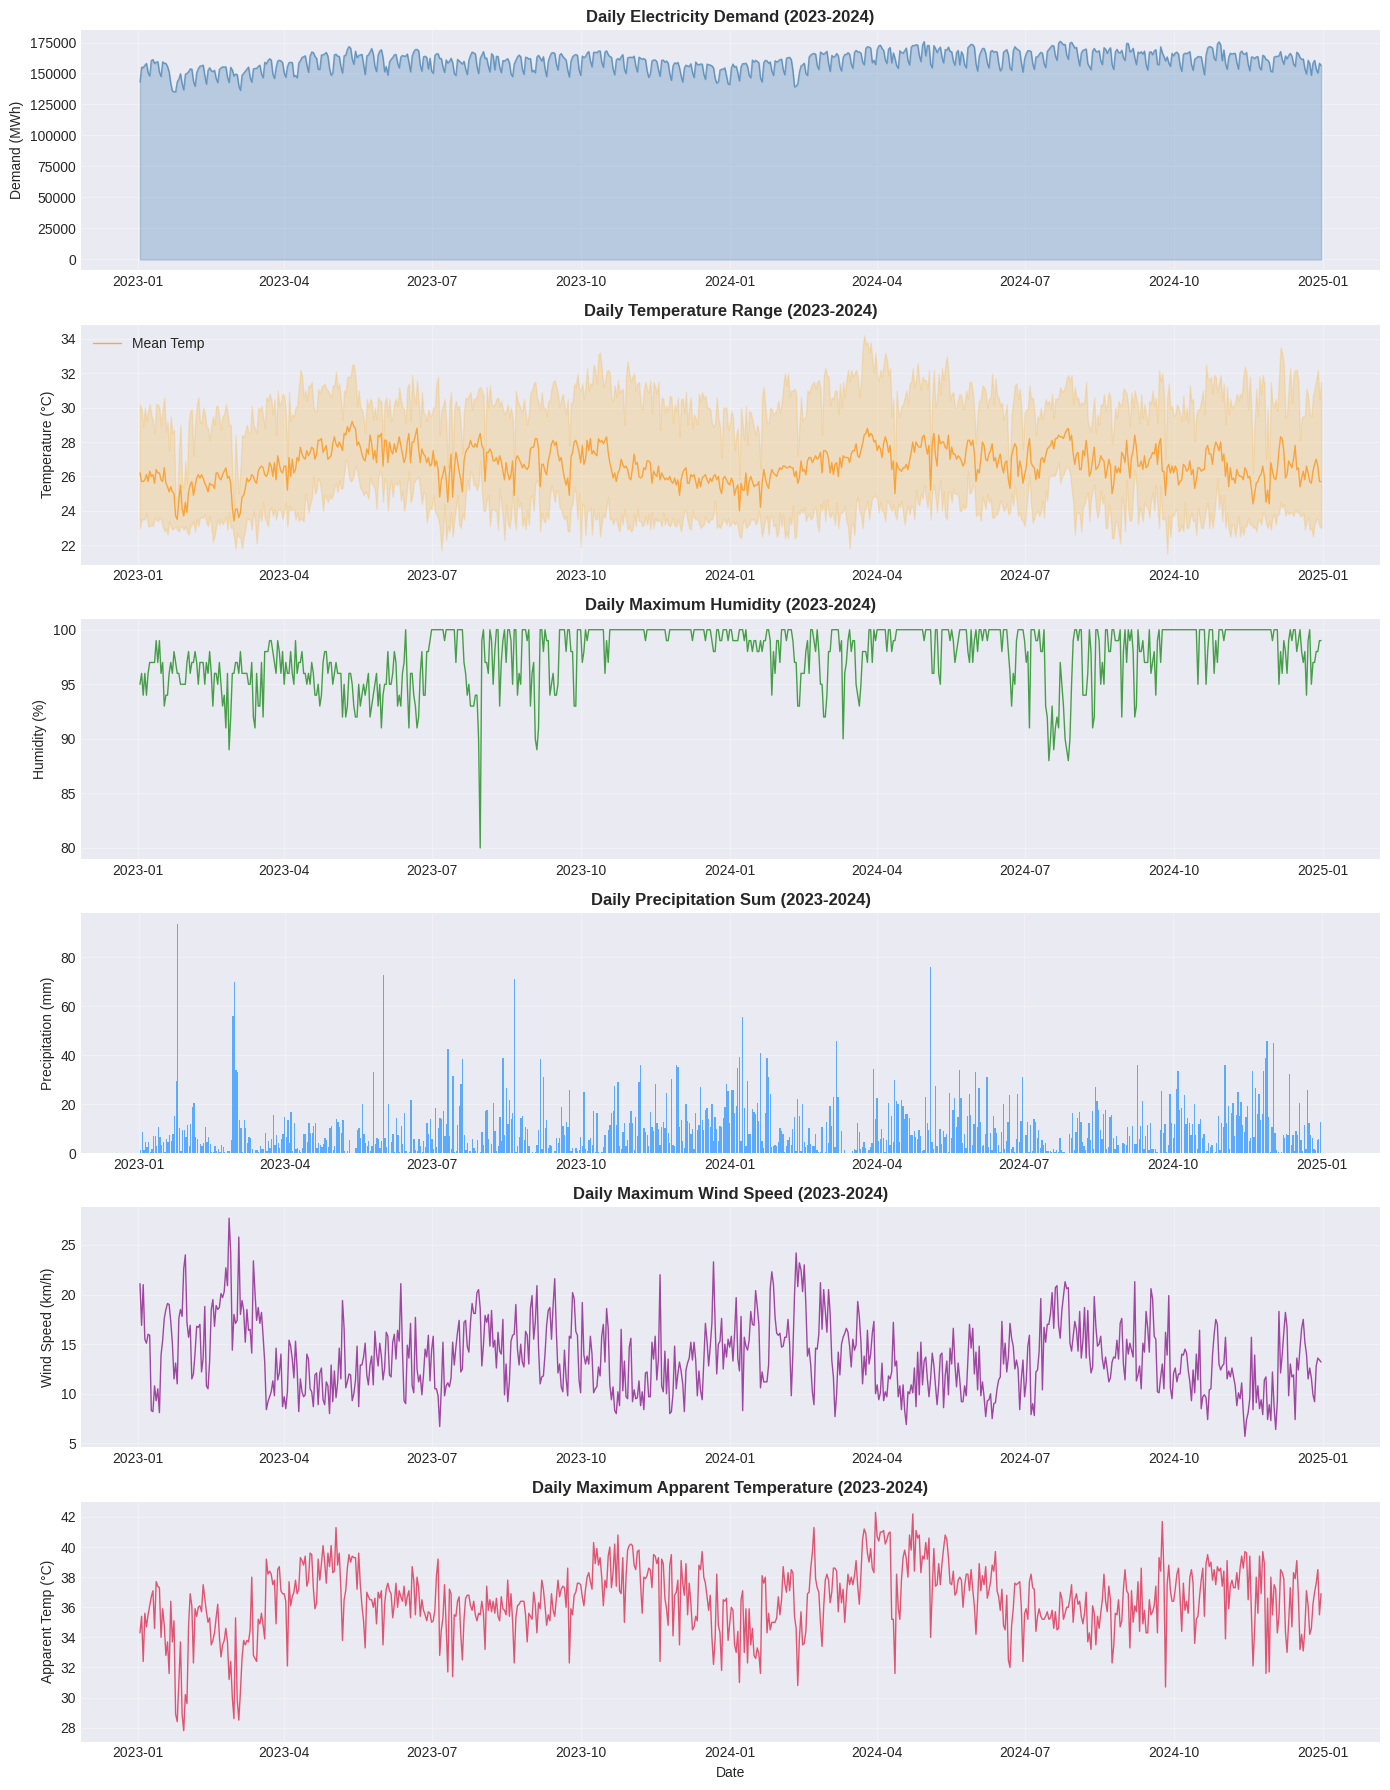

✓ All time series visualizations created


In [14]:
# Time series plot of demand and all weather factors
fig, axes = plt.subplots(6, 1, figsize=(14, 18))

# 1. Demand over time
axes[0].plot(df['date'], df['demand_mwh'], linewidth=1, alpha=0.7, color='steelblue')
axes[0].fill_between(df['date'], df['demand_mwh'], alpha=0.3, color='steelblue')
axes[0].set_title('Daily Electricity Demand (2023-2024)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Demand (MWh)')
axes[0].grid(True, alpha=0.3)

# 2. Temperature over time
axes[1].plot(df['date'], df['temp_mean'], label='Mean Temp', linewidth=1, alpha=0.7, color='darkorange')
axes[1].fill_between(df['date'], df['temp_max'], df['temp_min'], alpha=0.2, color='orange')
axes[1].set_title('Daily Temperature Range (2023-2024)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Humidity over time
axes[2].plot(df['date'], df['humidity_max'], linewidth=1, alpha=0.7, color='green')
axes[2].set_title('Daily Maximum Humidity (2023-2024)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Humidity (%)')
axes[2].grid(True, alpha=0.3)

# 4. Precipitation over time
axes[3].bar(df['date'], df['precipitation'], alpha=0.7, color='dodgerblue')
axes[3].set_title('Daily Precipitation Sum (2023-2024)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Precipitation (mm)')
axes[3].grid(True, alpha=0.3)

# 5. Wind Speed over time
axes[4].plot(df['date'], df['wind_speed'], linewidth=1, alpha=0.7, color='purple')
axes[4].set_title('Daily Maximum Wind Speed (2023-2024)', fontsize=12, fontweight='bold')
axes[4].set_ylabel('Wind Speed (km/h)')
axes[4].grid(True, alpha=0.3)

# 6. Apparent Temperature over time
axes[5].plot(df['date'], df['apparent_temp_max'], linewidth=1, alpha=0.7, color='crimson')
axes[5].set_title('Daily Maximum Apparent Temperature (2023-2024)', fontsize=12, fontweight='bold')
axes[5].set_ylabel('Apparent Temp (°C)')
axes[5].set_xlabel('Date')
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ All time series visualizations created")

### 4.2 Correlation Analysis & Weather-Demand Relationship

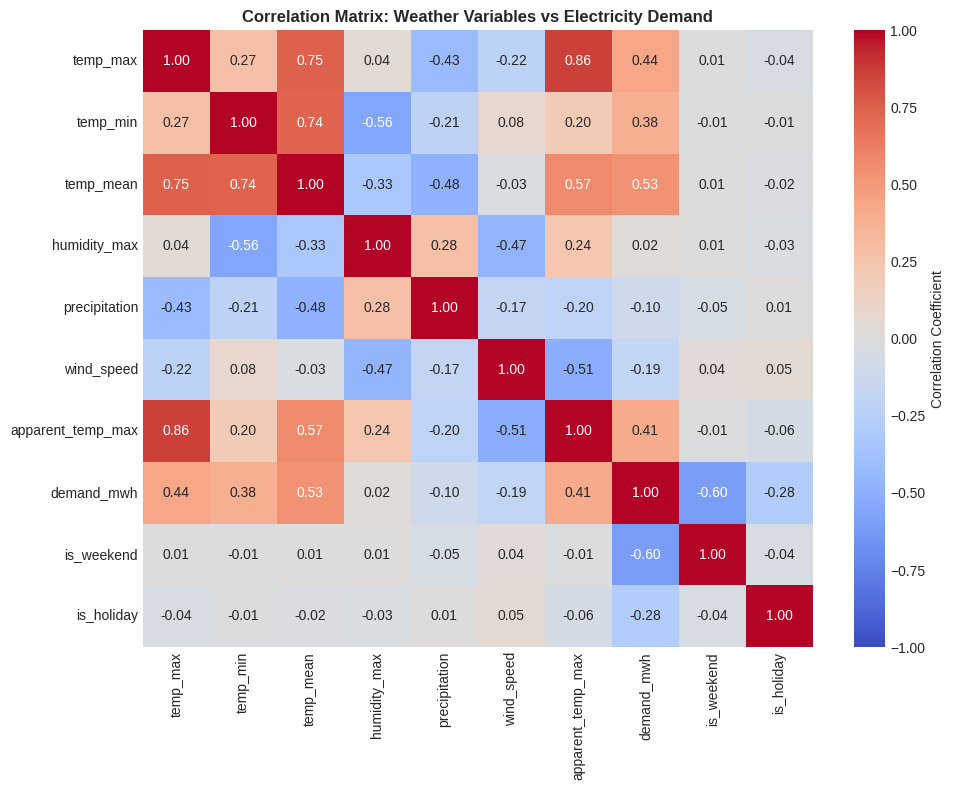

In [15]:
# Correlation heatmap
numeric_cols = ['temp_max', 'temp_min', 'temp_mean', 'humidity_max', 'precipitation',
                'wind_speed', 'apparent_temp_max', 'demand_mwh', 'is_weekend', 'is_holiday']
correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation Coefficient'}, vmin=-1, vmax=1)
plt.title('Correlation Matrix: Weather Variables vs Electricity Demand', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

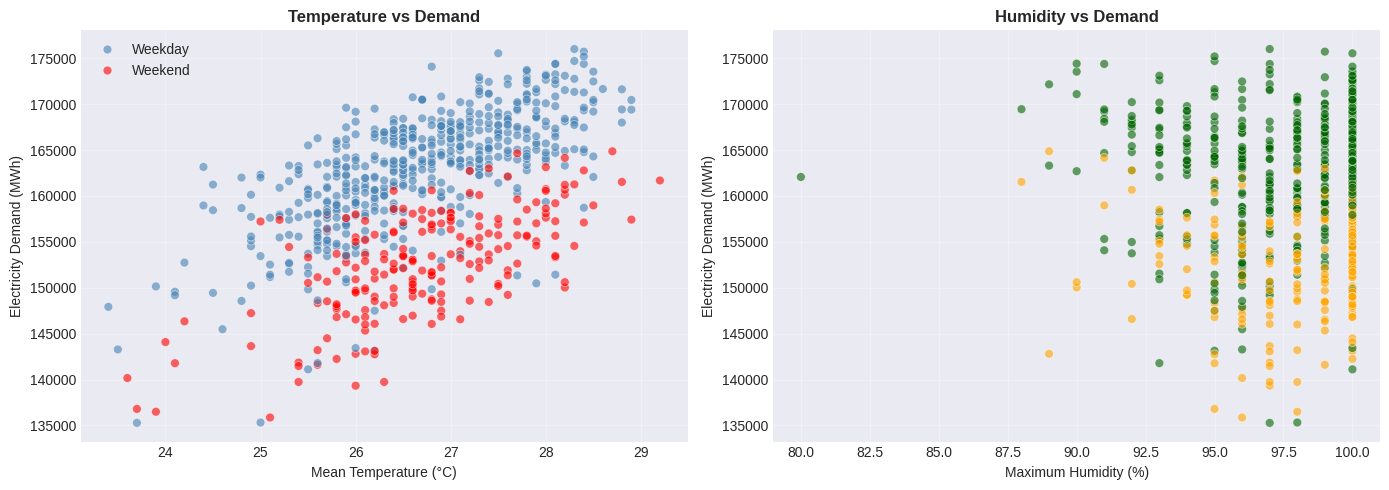

<Figure size 640x480 with 0 Axes>

In [17]:

# Scatter plot: Temperature vs Demand
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dùng sns.scatterplot để tự động chia màu (hue) theo is_weekend
sns.scatterplot(data=df, x='temp_mean', y='demand_mwh', hue='is_weekend',
                palette=['steelblue', 'red'], alpha=0.6, s=40, ax=axes[0])
axes[0].set_xlabel('Mean Temperature (°C)')
axes[0].set_ylabel('Electricity Demand (MWh)')
axes[0].set_title('Temperature vs Demand', fontweight='bold')
axes[0].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ['Weekday', 'Weekend'], title='')

# Scatter plot: Humidity vs Demand
sns.scatterplot(data=df, x='humidity_max', y='demand_mwh', hue='is_weekend',
                palette=['darkgreen', 'orange'], alpha=0.6, s=40, ax=axes[1])
axes[1].set_xlabel('Maximum Humidity (%)')
axes[1].set_ylabel('Electricity Demand (MWh)')
axes[1].set_title('Humidity vs Demand', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

### 4.3 Demand by Day Type (Weekday vs Weekend vs Holiday)

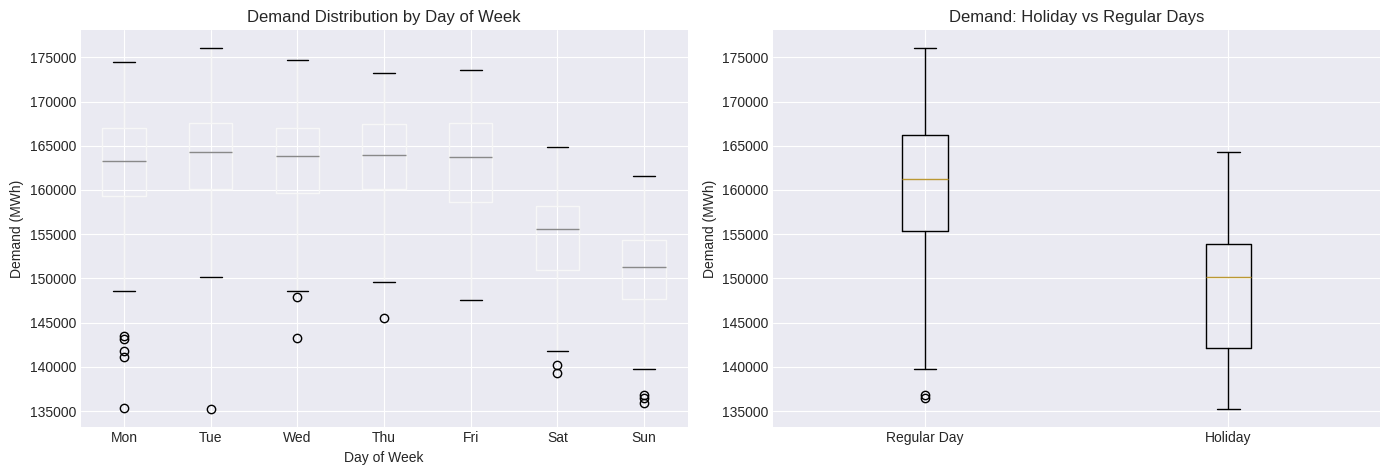


DEMAND STATISTICS BY DAY TYPE

By Day of Week:
                mean      std     min     max
day_name                                     
Friday     162824.40  5932.64  147500  173548
Monday     162007.65  7432.12  135319  174420
Saturday   154662.72  5380.06  139332  164870
Sunday     150662.22  5411.28  135867  161534
Thursday   163498.93  5640.41  145489  173259
Tuesday    163527.40  6430.10  135278  176014
Wednesday  163173.89  6003.18  143281  174707

Holiday vs Regular Days:
                 mean      std     min     max
is_holiday                                    
0           160469.49  7402.14  136493  176014
1           148929.35  8262.51  135278  164320


In [18]:
# Create day type labels
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
             4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['day_name'] = df['day_of_week'].map(day_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot by day of week
df.boxplot(column='demand_mwh', by='day_of_week', ax=axes[0])
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Demand (MWh)')
axes[0].set_title('Demand Distribution by Day of Week')

# Robustly set tick positions to match 7 day labels
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
tick_positions = list(range(1, len(day_labels) + 1))
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(day_labels)
plt.sca(axes[0])
plt.xticks(tick_positions, day_labels)

# Demand by holiday status
holiday_data = []
holiday_labels = []
for is_hol in [0, 1]:
    holiday_data.append(df[df['is_holiday'] == is_hol]['demand_mwh'])
    holiday_labels.append('Holiday' if is_hol == 1 else 'Regular Day')

axes[1].boxplot(holiday_data, labels=holiday_labels)
axes[1].set_ylabel('Demand (MWh)')
axes[1].set_title('Demand: Holiday vs Regular Days')

plt.suptitle('')
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n{'='*50}")
print(f"DEMAND STATISTICS BY DAY TYPE")
print(f"{'='*50}")
print(f"\nBy Day of Week:")
print(df.groupby('day_name')['demand_mwh'].agg(['mean', 'std', 'min', 'max']).round(2))
print(f"\nHoliday vs Regular Days:")
print(df.groupby('is_holiday')['demand_mwh'].agg(['mean', 'std', 'min', 'max']).round(2))

## Step 5: Feature Engineering - Lag & Rolling Features

### 5.1 Create Lag Features (NO FUTURE DATA LEAKAGE)

In [19]:
print("⏳ Đang nhào nặn đặc trưng (Feature Engineering)...")

# -------------------------------------------------------------------------
# 1. NHÓM ĐẶC TRƯNG ĐỘ TRỄ (LAG FEATURES)
# -------------------------------------------------------------------------
# Lượng điện của ngày hôm qua và cùng kỳ tuần trước
df['demand_lag_1'] = df['demand_mwh'].shift(1)
df['demand_lag_7'] = df['demand_mwh'].shift(7)

# Thời tiết của ngày hôm qua
df['temp_mean_lag_1'] = df['temp_mean'].shift(1)
df['temp_max_lag_1'] = df['temp_max'].shift(1)

# -------------------------------------------------------------------------
# 2. NHÓM TRUNG BÌNH TRƯỢT (ROLLING FEATURES)
# -------------------------------------------------------------------------
df['demand_rolling_7'] = df['demand_mwh'].shift(1).rolling(window=7, min_periods=1).mean()
df['demand_rolling_30'] = df['demand_mwh'].shift(1).rolling(window=30, min_periods=1).mean()

# Với thời tiết, ta giả định có được bản tin dự báo thời tiết của ngày hôm nay,
# nên ta lấy thẳng rolling đến ngày hôm nay (không cần shift biến temp/humidity)
df['temp_mean_rolling_3'] = df['temp_mean'].rolling(window=3, min_periods=1).mean()
df['humidity_rolling_3'] = df['humidity_max'].rolling(window=3, min_periods=1).mean()

# -------------------------------------------------------------------------
# 3. NHÓM TƯƠNG TÁC (INTERACTION FEATURES)
# -------------------------------------------------------------------------
# Chỉ số nhiệt bức bối = Nhiệt độ * Độ ẩm
df['temp_humidity_interaction'] = (df['temp_mean'] * df['humidity_max']) / 100
df['is_day_before_holiday'] = df['is_holiday'].shift(-1).fillna(0).astype(int)
df['is_day_after_holiday'] = df['is_holiday'].shift(1).fillna(0).astype(int)

# -------------------------------------------------------------------------
# 4. BƯỚC DỌN DẸP DỮ LIỆU (DATA CLEANING)
# -------------------------------------------------------------------------
# Lệnh shift(7) sẽ khiến 7 dòng đầu tiên bị NaN (vì không có dữ liệu của tuần trước đó)
# Các mô hình học máy rất nhạy cảm với NaN, ta phải xóa bỏ các dòng khởi động này.
original_shape = df.shape[0]
df = df.dropna().reset_index(drop=True)

print(f"  - Tổng số dòng ban đầu: {original_shape}")
print(f"  - Số dòng sau khi cắt bỏ NaN: {df.shape[0]}")
print(f"  - Tổng số cột hiện tại: {df.shape[1]}")
print(f"\nMột góc nhìn vào dữ liệu mới:")
display(df[['date', 'demand_mwh', 'demand_lag_1', 'demand_rolling_7', 'temp_humidity_interaction']].head())

⏳ Đang nhào nặn đặc trưng (Feature Engineering)...
  - Tổng số dòng ban đầu: 730
  - Số dòng sau khi cắt bỏ NaN: 723
  - Tổng số cột hiện tại: 27

Một góc nhìn vào dữ liệu mới:


,date,demand_mwh,demand_lag_1,demand_rolling_7,temp_humidity_interaction
0,2023-01-09,160469,148094.0,152363.714286,25.220
1,2023-01-10,161243,160469.0,154840.000000,25.317
2,2023-01-11,158049,161243.0,155715.857143,24.832
3,2023-01-12,159202,158049.0,156182.285714,26.136
4,2023-01-13,159525,159202.0,156552.428571,25.414


### 5.2 Prepare Data for Modeling

In [20]:
# Remove rows with NaN values from lag and rolling features (first 30 days)
df_clean = df.dropna().reset_index(drop=True)

print(f"Original dataset: {df.shape[0]} rows")
print(f"After removing NaN (lag/rolling): {df_clean.shape[0]} rows")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

# ==============================================================================
# BƯỚC 1: ĐỊNH NGHĨA CÁC ĐẶC TRƯNG (FEATURE SELECTION)
# ==============================================================================
feature_cols = [
    # 1. Weather features (Thời tiết hiện tại)
    'temp_max', 'temp_min', 'temp_mean', 'humidity_max',
    'precipitation', 'wind_speed', 'apparent_temp_max',

    # 2. Lag features (Độ trễ quá khứ)
    'demand_lag_1', 'demand_lag_7',
    'temp_mean_lag_1', 'temp_max_lag_1',

    # 3. Rolling features (Trung bình trượt)
    'demand_rolling_7', 'demand_rolling_30',
    'temp_mean_rolling_3', 'humidity_rolling_3',

    # 4. Temporal features (Thời gian & Ngày lễ)
    # ĐÃ BỔ SUNG day_of_week và các cột giáp lễ
    'is_weekend', 'is_holiday', 'day_of_week',
    'month', 'day_of_year', 'week_of_year',
    'is_day_before_holiday', 'is_day_after_holiday',

    # 5. Interaction features (Tương tác)
    'temp_humidity_interaction'
]

target_col = 'demand_mwh'

X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

# Giữ lại cột 'date' ở một biến riêng để sau này vẽ biểu đồ Test cho đẹp
dates = df_clean['date'].copy()

Original dataset: 723 rows
After removing NaN (lag/rolling): 723 rows
Rows removed: 0


## Step 6: Train/Test Split & Baseline Forecast

### 6.1 Chronological Split (80% train, 20% test)

In [21]:
# ==============================================================================
# BƯỚC 2: CHIA TẬP TRAIN VÀ TEST (TIME-SERIES SPLIT)
# ==============================================================================
split_ratio = 0.8
split_index = int(len(df_clean) * split_ratio)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

dates_train = dates.iloc[:split_index]
dates_test  = dates.iloc[split_index:]

# ==============================================================================
# BÁO CÁO NGHIỆM THU DỮ LIỆU
# ==============================================================================
print("="*60)
print(f"Features: {len(feature_cols)}")
print(f"Target: {target_col}\n")

print(f"Train: {X_train.shape[0]} ngày (Từ {dates_train.iloc[0].strftime('%Y-%m-%d')} đến {dates_train.iloc[-1].strftime('%Y-%m-%d')})")
print(f"Test:  {X_test.shape[0]} ngày (Từ {dates_test.iloc[0].strftime('%Y-%m-%d')} đến {dates_test.iloc[-1].strftime('%Y-%m-%d')})")
print("="*60)

if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("⚠ Still NaN")
else:
    print("✓ No Nan")

Features: 24
Target: demand_mwh

Train: 578 ngày (Từ 2023-01-09 đến 2024-08-08)
Test:  145 ngày (Từ 2024-08-09 đến 2024-12-31)
✓ No Nan


### 6.2 Establish Naive Baseline (Lag-1 Forecast)

In [22]:
# Baseline: predict today's demand equals yesterday's demand (lag-1)
baseline_pred_test = X_test['demand_lag_1'].values

# Compute baseline metrics
baseline_mae = mean_absolute_error(y_test, baseline_pred_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred_test))
baseline_r2 = r2_score(y_test, baseline_pred_test)
print("Calculating Baseline (Lag-1) performance...")
baseline_pred_test = X_test['demand_lag_1']
baseline_mae = mean_absolute_error(y_test, baseline_pred_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred_test))
baseline_r2 = r2_score(y_test, baseline_pred_test)

print("✓ Baseline calculated")
print("="*60)
print("BASELINE MODEL: Predict today = yesterday's demand (LAG-1)")
print("="*60)
print(f"\nBaseline Performance on Test Set:")
print(f"  MAE:  {baseline_mae:8.2f} MWh")
print(f"  RMSE: {baseline_rmse:8.2f} MWh")
print(f"  R²:   {baseline_r2:8.4f}")
print(f"\nThis baseline will be compared against ML models.")

Calculating Baseline (Lag-1) performance...
✓ Baseline calculated
BASELINE MODEL: Predict today = yesterday's demand (LAG-1)

Baseline Performance on Test Set:
  MAE:   4678.17 MWh
  RMSE:  6367.63 MWh
  R²:    -0.1517

This baseline will be compared against ML models.


## Step 7: Model Training – Regression & Classification

### 7.1 Standardize Features

In [23]:
# Standardize features (critical for Linear Regression)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features standardized using StandardScaler")
print(f"\nScaled data statistics:")
print(f"  Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"  Test mean:  {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")

✓ Features standardized using StandardScaler

Scaled data statistics:
  Train mean: 0.000000, std: 1.000000
  Test mean:  0.265238, std: 0.906738


### 7.2 Task 1 – Regression Models (Exact MWh Prediction)

In [24]:
# Try with linear regression
if 'X_train_scaled' not in dir() or 'X_test_scaled' not in dir():
    print("⚠ Scaler not found — running StandardScaler now...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("✓ Features scaled.")

print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

lr_train_mae = mean_absolute_error(y_train, y_train_pred_lr)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
lr_train_r2 = r2_score(y_train, y_train_pred_lr)

lr_test_mae = mean_absolute_error(y_test, y_test_pred_lr)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
lr_test_r2 = r2_score(y_test, y_test_pred_lr)

print(f"\n{'Model':<25} {'MAE (MWh)':<18} {'RMSE (MWh)':<18} {'R² Score':<12}")
print("-"*70)
print(f"{'Baseline (Lag-1)':<25} {baseline_mae:<18.2f} {baseline_rmse:<18.2f} {baseline_r2:<12.4f}")
print(f"{'Linear Regression':<25} {lr_test_mae:<18.2f} {lr_test_rmse:<18.2f} {lr_test_r2:<12.4f}")

Training Linear Regression...

Model                     MAE (MWh)          RMSE (MWh)         R² Score    
----------------------------------------------------------------------
Baseline (Lag-1)          4678.17            6367.63            -0.1517     
Linear Regression         8465.15            61250.19           -105.5647   


In [25]:
# Try with random forest
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

tscv = TimeSeriesSplit(n_splits=3)
base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=1
)
grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_

print("\n" + "="*50)
print("Best param")
print("="*50)
print(f"Number of tree (n_estimators): {grid_search.best_params_['n_estimators']}")
print(f"Max depth (max_depth): {grid_search.best_params_['max_depth']}")
print(f"Min sample split (min_samples_split): {grid_search.best_params_['min_samples_split']}")

y_test_pred_best_rf = best_rf_model.predict(X_test)
best_rf_mae = mean_absolute_error(y_test, y_test_pred_best_rf)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_best_rf))
best_rf_r2 = r2_score(y_test, y_test_pred_best_rf)

print(f"\n{'Model':<25} {'MAE (MWh)':<18} {'RMSE (MWh)':<18} {'R² Score':<12}")
print("-"*70)
print(f"{'Baseline (Lag-1)':<25} {baseline_mae:<18.2f} {baseline_rmse:<18.2f} {baseline_r2:<12.4f}")
print(f"{'Random Forest':<25} {best_rf_mae:<18.2f} {best_rf_rmse:<18.2f} {best_rf_r2:<12.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best param
Number of tree (n_estimators): 200
Max depth (max_depth): 10
Min sample split (min_samples_split): 5

Model                     MAE (MWh)          RMSE (MWh)         R² Score    
----------------------------------------------------------------------
Baseline (Lag-1)          4678.17            6367.63            -0.1517     
Linear Regression         1672.01            2155.26            0.8681      


In [26]:
import xgboost as xgb
import catboost as cb

In [30]:
#Try XGBoost
print("Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=200,       # Số lượng vòng lặp (số cây)
    max_depth=6,            # Trong Boosting, cây thường nông hơn Random Forest (từ 4-8)
    learning_rate=0.05,     # Tốc độ học: Nhỏ giúp mô hình học kỹ và hội tụ tốt hơn
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_test_pred_xgb = xgb_model.predict(X_test)
best_rf_mae = mean_absolute_error(y_test, y_test_pred_xgb)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
best_rf_r2 = r2_score(y_test, y_test_pred_xgb)

print("✓ XGBoost trained\n")
print(f"\n{'Model':<25} {'MAE (MWh)':<18} {'RMSE (MWh)':<18} {'R² Score':<12}")
print("-"*70)
print(f"{'Baseline (Lag-1)':<25} {baseline_mae:<18.2f} {baseline_rmse:<18.2f} {baseline_r2:<12.4f}")
print(f"{'XGBoost Regressor':<25} {best_rf_mae:<18.2f} {best_rf_rmse:<18.2f} {best_rf_r2:<12.4f}")

Training XGBoost Regressor...
✓ XGBoost trained


Model                     MAE (MWh)          RMSE (MWh)         R² Score    
----------------------------------------------------------------------
Baseline (Lag-1)          4678.17            6367.63            -0.1517     
XGBoost Regressor         1575.89            2065.70            0.8788      


In [31]:
# Try CatBoost
print("Training CatBoost Regressor...")
cat_model = cb.CatBoostRegressor(
    iterations=200,         # Tương đương n_estimators
    depth=6,                # Độ sâu của cây
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train, y_train)
y_test_pred_cat = cat_model.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, y_test_pred_xgb)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
best_rf_r2 = r2_score(y_test, y_test_pred_xgb)

print("✓ CatBoost trained\n")
print(f"\n{'Model':<25} {'MAE (MWh)':<18} {'RMSE (MWh)':<18} {'R² Score':<12}")
print("-"*70)
print(f"{'Baseline (Lag-1)':<25} {baseline_mae:<18.2f} {baseline_rmse:<18.2f} {baseline_r2:<12.4f}")
print(f"{'CatBoost Regressor':<25} {best_rf_mae:<18.2f} {best_rf_rmse:<18.2f} {best_rf_r2:<12.4f}")

Training CatBoost Regressor...
✓ CatBoost trained


Model                     MAE (MWh)          RMSE (MWh)         R² Score    
----------------------------------------------------------------------
Baseline (Lag-1)          4678.17            6367.63            -0.1517     
CatBoost Regressor        1575.89            2065.70            0.8788      


In [32]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

# Core of PPSO
class PPSO:
    def __init__(self, obj_func, bounds, num_particles=15, max_iter=20):
        self.obj_func = obj_func
        self.bounds = np.array(bounds)
        self.num_particles = num_particles
        self.max_iter = max_iter
        self.dim = len(bounds)

    def optimize(self):
        X = np.random.uniform(self.bounds[:, 0], self.bounds[:, 1], (self.num_particles, self.dim))
        V = np.zeros_like(X)
        Theta = np.random.uniform(0, 2 * np.pi, (self.num_particles, self.dim))

        pbest_X = np.copy(X)
        pbest_scores = np.array([self.obj_func(x) for x in X])

        gbest_idx = np.argmin(pbest_scores)
        gbest_X = np.copy(pbest_X[gbest_idx])
        gbest_score = pbest_scores[gbest_idx]

        print(f"--- Start finding the best param by PPSO ---")
        for t in range(self.max_iter):
            for i in range(self.num_particles):
                cos_t = np.cos(Theta[i])
                sin_t = np.sin(Theta[i])

                term1 = (np.abs(cos_t)**2) * sin_t * (pbest_X[i] - X[i])
                term2 = (np.abs(sin_t)**2) * cos_t * (gbest_X - X[i])
                V[i] = term1 + term2

                v_max = (np.abs(cos_t)**2) * (self.bounds[:, 1] - self.bounds[:, 0])
                V[i] = np.clip(V[i], -v_max, v_max)

                X[i] = np.clip(X[i] + V[i], self.bounds[:, 0], self.bounds[:, 1])
                Theta[i] = Theta[i] + np.abs(cos_t + sin_t) * (2 * np.pi)

                score = self.obj_func(X[i])

                if score < pbest_scores[i]:
                    pbest_scores[i] = score
                    pbest_X[i] = np.copy(X[i])
                    if score < gbest_score:
                        gbest_score = score
                        gbest_X = np.copy(X[i])

            print(f"Repeat {t+1}/{self.max_iter} | Best CV RMSE: {gbest_score:.4f}")

        return gbest_X

# ==========================================
# KHUNG MÔ HÌNH CATBOOST-PPSO
# ==========================================
class CatBoost_PPSO_Model:
    def __init__(self, cat_features=None, k_folds=3):
        self.cat_features = cat_features
        self.k_folds = k_folds
        self.best_params = {}
        self.final_model = None

    def _objective_function(self, params):
        n_estimators, depth = int(params[0]), int(params[1])
        learning_rate, l2_leaf_reg = params[2], params[3]

        kf = KFold(n_splits=self.k_folds, shuffle=True, random_state=42)
        cv_rmse = []

        for train_idx, val_idx in kf.split(self.X_train):
            X_tr, X_val = self.X_train.iloc[train_idx], self.X_train.iloc[val_idx]
            y_tr, y_val = self.y_train.iloc[train_idx], self.y_train.iloc[val_idx]

            model = CatBoostRegressor(
                iterations=n_estimators, depth=depth,
                learning_rate=learning_rate, l2_leaf_reg=l2_leaf_reg,
                cat_features=self.cat_features, loss_function='RMSE', verbose=0
            )
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=20)
            cv_rmse.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))

        return np.mean(cv_rmse)

    def fit(self, X_train, y_train, param_bounds, particles=15, iter=20):
        self.X_train = X_train
        self.y_train = y_train

        optimizer = PPSO(obj_func=self._objective_function, bounds=param_bounds, num_particles=particles, max_iter=iter)
        best_X = optimizer.optimize()

        self.best_params = {
            'iterations': int(best_X[0]),
            'depth': int(best_X[1]),
            'learning_rate': best_X[2],
            'l2_leaf_reg': best_X[3]
        }
        print(f"\n✓ Best parameter: {self.best_params}")
        self.final_model = CatBoostRegressor(**self.best_params, cat_features=self.cat_features, loss_function='RMSE', verbose=0)
        self.final_model.fit(X_train, y_train)
        print("✓ Train successfull")

    def predict(self, X):
        return self.final_model.predict(X)

bounds = [(100, 800), (4, 10), (0.005, 0.3), (1.0, 20.0)]

cat_ppso_model = CatBoost_PPSO_Model(cat_features=None, k_folds=3)
cat_ppso_model.fit(
    X_train=X_train,
    y_train=y_train,
    param_bounds=bounds,
    particles=35,
    iter=60
)

y_test_pred_cat_ppso = cat_ppso_model.predict(X_test)

--- Start finding the best param by PPSO ---
Repeat 1/60 | Best CV RMSE: 1761.6518
Repeat 2/60 | Best CV RMSE: 1703.2142
Repeat 3/60 | Best CV RMSE: 1703.2142
Repeat 4/60 | Best CV RMSE: 1703.2142
Repeat 5/60 | Best CV RMSE: 1703.2142
Repeat 6/60 | Best CV RMSE: 1703.2142
Repeat 7/60 | Best CV RMSE: 1703.2142
Repeat 8/60 | Best CV RMSE: 1703.2142


KeyboardInterrupt: 

## Step 8: Model Evaluation & Visualization

### 8.1 Regression Model Predictions vs Actual


                                🏆 LEADERBOARD 🏆                                 


,R2 (↑),WI (↑),RMSE (↓),MAE (↓),MAPE (%) (↓),RAE (↓)
Model,,,,,,
CatBoost-PPSO,0.8986,0.9728,1891.1943,1479.0863,0.9030,0.3033
XGBoost,0.8883,0.9696,1985.6498,1512.9232,0.9276,0.3102
CatBoost,0.8869,0.9691,1997.3929,1595.4053,0.9729,0.3271
Random Forest,0.8743,0.9656,2106.3624,1641.3398,1.0058,0.3365
Baseline (Lag-1),-0.1299,0.6770,6314.2304,4629.0625,2.8560,0.9492
Linear Regression,-120.1750,0.0651,65390.5254,8977.0305,5.6728,1.8407


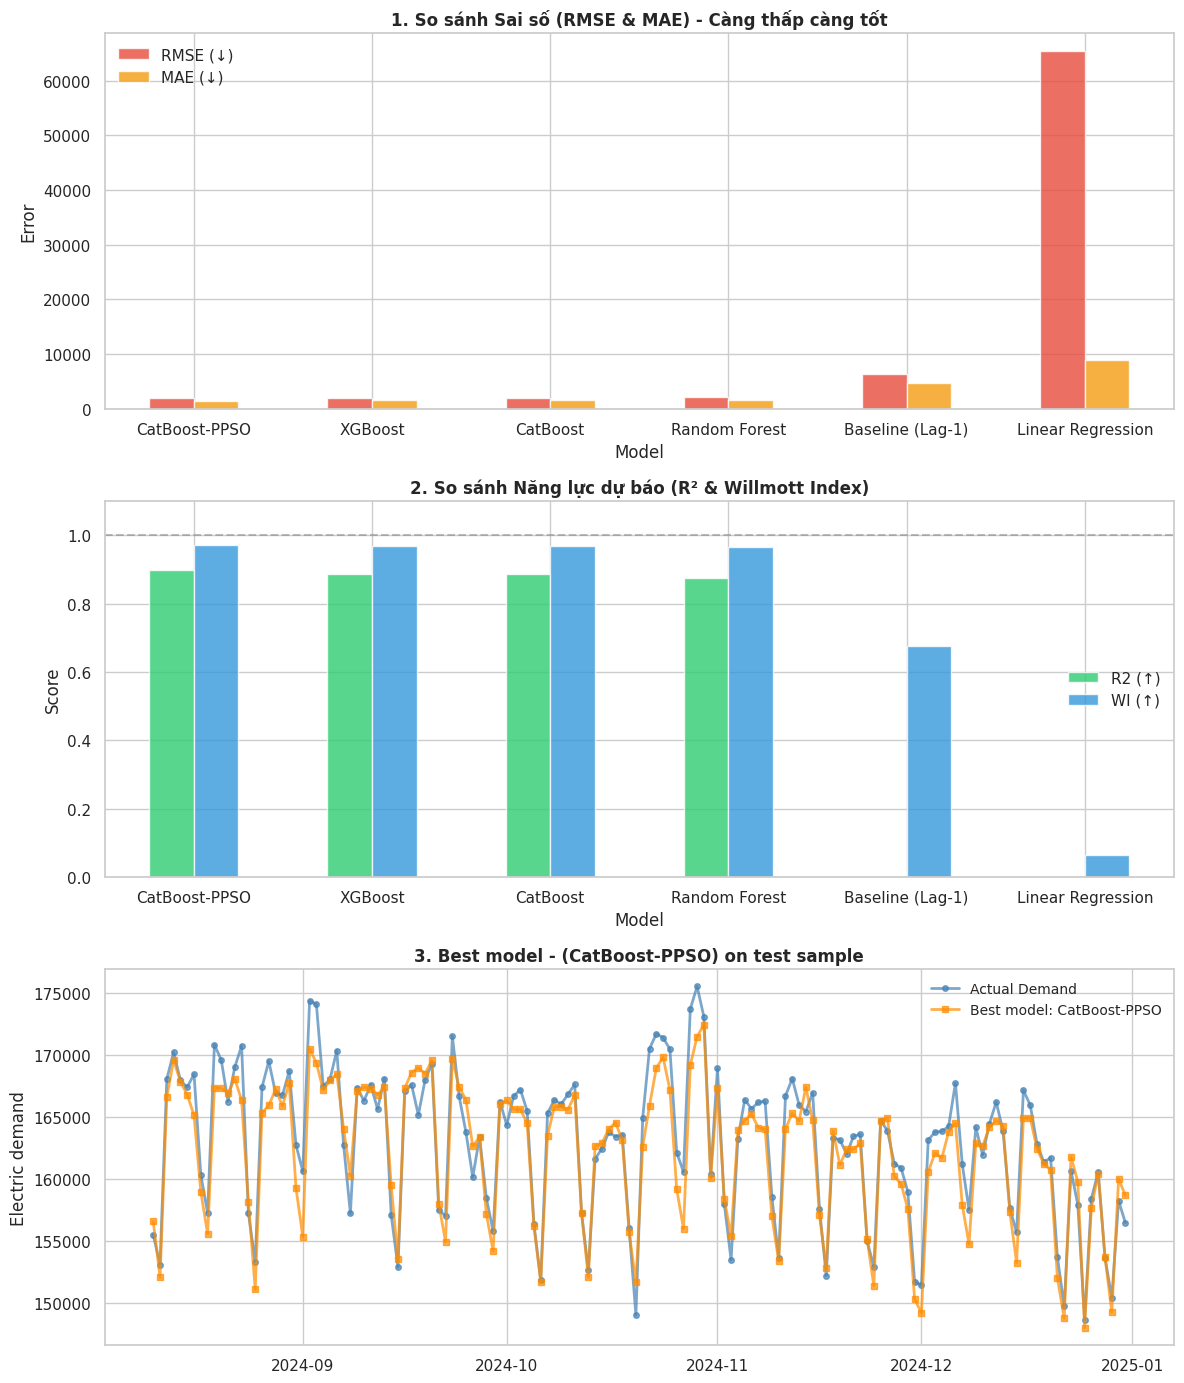

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def compare_and_visualize_models(y_true, predictions_dict, dates=None):
    metrics_list = []
    y_mean = np.mean(y_true)

    for model_name, y_pred in predictions_dict.items():
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
        mae = mean_absolute_error(y_true, y_pred)
        rae = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true - y_mean))

        num = np.sum((y_true - y_pred)**2)
        den = np.sum((np.abs(y_pred - y_mean) + np.abs(y_true - y_mean))**2)
        wi = 1 - (num / den)

        metrics_list.append({
            'Model': model_name,
            'R2 (↑)': r2,
            'WI (↑)': wi,
            'RMSE (↓)': rmse,
            'MAE (↓)': mae,
            'MAPE (%) (↓)': mape,
            'RAE (↓)': rae
        })

    df_metrics = pd.DataFrame(metrics_list).set_index('Model')
    df_metrics = df_metrics.sort_values(by='MAE (↓)', ascending=True)

    print("\n" + "🏆 LEADERBOARD 🏆".center(80))
    print("="*85)
    display(df_metrics.round(4))
    print("="*85)

    # ==========================================
    # 2. TRỰC QUAN HÓA
    # ==========================================
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(12, 14))

    # Biểu đồ 1: Sai số (RMSE và MAE)
    ax1 = plt.subplot(3, 1, 1)
    df_metrics[['RMSE (↓)', 'MAE (↓)']].plot(kind='bar', ax=ax1, color=['#e74c3c', '#f39c12'], alpha=0.8)
    ax1.set_title('1. So sánh Sai số (RMSE & MAE) - Càng thấp càng tốt', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Error')
    ax1.tick_params(axis='x', rotation=0)

    # Biểu đồ 2: Độ khớp (R2 và WI)
    ax2 = plt.subplot(3, 1, 2)
    df_metrics[['R2 (↑)', 'WI (↑)']].plot(kind='bar', ax=ax2, color=['#2ecc71', '#3498db'], alpha=0.8)
    ax2.set_title('2. So sánh Năng lực dự báo (R² & Willmott Index)', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Score')
    ax2.set_ylim(0, 1.1)
    ax2.tick_params(axis='x', rotation=0)
    ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

    # Biểu đồ 3: Chuỗi thời gian thực tế vs Mô hình TỐT NHẤT
    ax3 = plt.subplot(3, 1, 3)
    best_model_name = df_metrics.index[0]
    best_predictions = predictions_dict[best_model_name]

    plot_dates = dates if dates is not None else np.arange(len(y_true))

    ax3.plot(plot_dates, y_true, 'o-', linewidth=2, markersize=4, label='Actual Demand', color='steelblue', alpha=0.7)
    ax3.plot(plot_dates, best_predictions, 's-', linewidth=2, markersize=4, label=f'Best model: {best_model_name}', color='darkorange', alpha=0.7)

    ax3.set_title(f'3. Best model - ({best_model_name}) on test sample', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Electric demand')
    ax3.legend(fontsize=10, loc='best')

    plt.tight_layout()
    plt.show()

# Comparing
predictions_to_compare = {
    'Random Forest': y_test_pred_best_rf,
    'Linear Regression': y_test_pred_lr,
    'CatBoost': y_test_pred_cat,
    'XGBoost': y_test_pred_xgb,
    'CatBoost-PPSO': y_test_pred_cat_ppso,
    'Baseline (Lag-1)': baseline_pred_test
}

compare_and_visualize_models(
    y_true=y_test.values,
    predictions_dict=predictions_to_compare,
    dates=dates_test
)

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_feature_importance(model, feature_names, model_name="Model", top_n=15):
    """
    Hàm vẽ biểu đồ Feature Importance hỗ trợ nhiều loại mô hình.

    Tham số:
    - model: Đối tượng mô hình đã được huấn luyện (fitted model).
    - feature_names: Danh sách tên các cột/đặc trưng (ví dụ: X_train.columns).
    - model_name: Tên mô hình để hiển thị trên tiêu đề biểu đồ (string).
    - top_n: Số lượng đặc trưng quan trọng nhất muốn hiển thị (int).
    """
    importances = None

    # 1. Dành cho class Custom của bạn (CatBoost_PPSO_Model)
    if hasattr(model, 'final_model') and hasattr(model.final_model, 'feature_importances_'):
        importances = model.final_model.feature_importances_

    # 2. Dành cho các mô hình dạng Cây (Random Forest, XGBoost, CatBoost gốc)
    elif hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_

    # 3. Dành cho các mô hình Tuyến tính (Linear Regression, Ridge, Lasso)
    elif hasattr(model, 'coef_'):
        # Lấy giá trị tuyệt đối của hệ số (coef) làm độ quan trọng
        importances = np.abs(model.coef_)
        # Xử lý trường hợp mảng 2 chiều (nếu có)
        if len(importances.shape) > 1:
            importances = np.mean(importances, axis=0)

    else:
        print(f"❌ Mô hình '{model_name}' không hỗ trợ trích xuất Feature Importance tự động.")
        return

    # Tạo DataFrame để trực quan hóa
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # Sắp xếp giảm dần và chỉ lấy top_n
    df_importance = df_importance.sort_values(by='Importance', ascending=False).head(top_n)

    # Vẽ biểu đồ
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Dùng palette màu viridis hoặc crest cho đẹp mắt
    ax = sns.barplot(x='Importance', y='Feature', data=df_importance, palette='crest')

    plt.title(f'Top {top_n} Mức độ quan trọng của đặc trưng\nMô hình: {model_name}',
              fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Mức độ quan trọng (Importance Score)', fontsize=12)
    plt.ylabel('Đặc trưng (Features)', fontsize=12)

    # Thêm số liệu trực tiếp lên cột
    for i in ax.containers:
        ax.bar_label(i, fmt='%.3f', padding=5, fontsize=10)

    plt.tight_layout()
    plt.show()

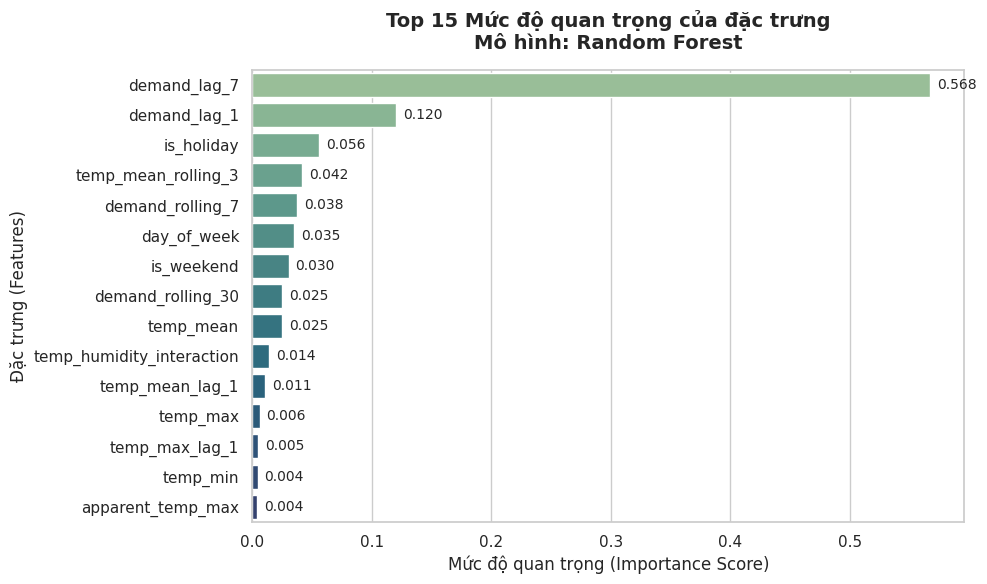

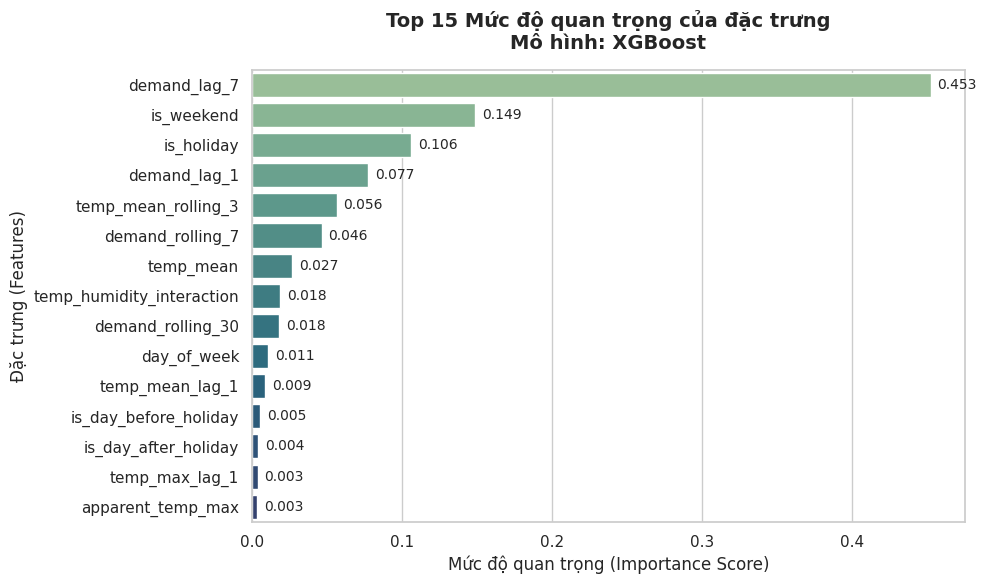

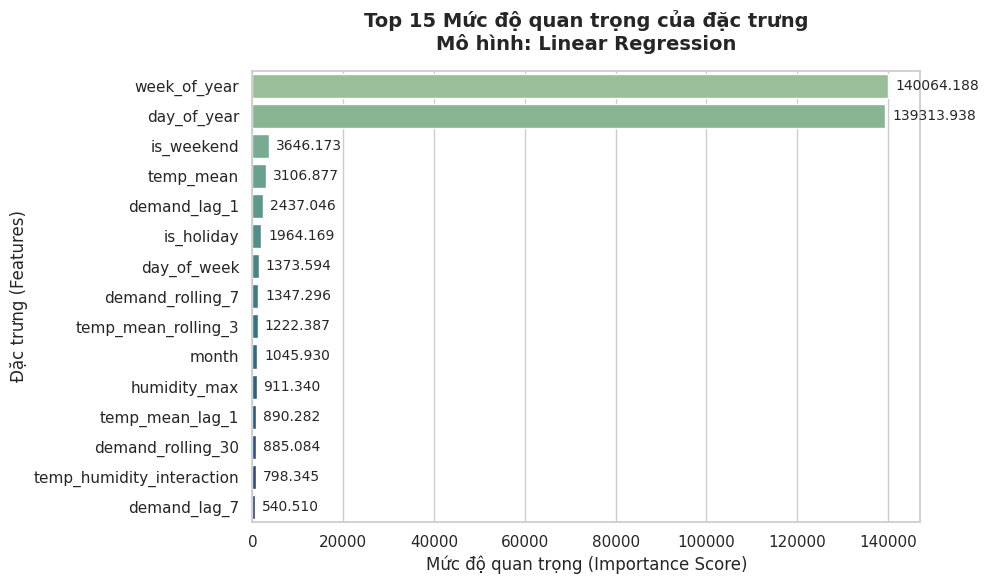

In [35]:
# rf_model và xgb_model là các biến bạn đã dùng model.fit()
plot_feature_importance(model=best_rf_model, feature_names=X_train.columns, model_name="Random Forest")
plot_feature_importance(model=xgb_model, feature_names=X_train.columns, model_name="XGBoost")

# lr_model là mô hình LinearRegression đã được fit
plot_feature_importance(model=lr_model, feature_names=X_train.columns, model_name="Linear Regression")

### 9.2 Demonstration: Make Predictions